In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import glob, os, re

import os
import numpy as np

import os, numpy as np, warnings

# Esta función carga un archivo binario que contiene matrices de adyacencia
# (probablemente guardadas como uint8, es decir, 0/1).
# Está diseñada para ser "segura": detecta archivos truncados,
# inconsistencias en el header, etc.
def load_run_bin_safe(path, allow_truncate=True):
    try:
        # obtiene el tamaño total del archivo en bytes
        size = os.path.getsize(path)

        # abrimos el archivo en modo binario para leer el header
        with open(path, "rb") as f:

            # N -> tamaño de la red (matriz NxN)
            N = np.fromfile(f, np.int32, 1)[0]

            # M_hdr -> número de matrices que el header dice que hay
            M_hdr = np.fromfile(f, np.int32, 1)[0]

            # alpha inicial
            alpha0 = np.fromfile(f, np.float64, 1)[0]

            # incremento de alpha entre matrices consecutivas
            dalpha = np.fromfile(f, np.float64, 1)[0]

            # posición actual del puntero → aquí empieza el bloque de matrices
            offset = f.tell()

        # cada matriz ocupa N*N bytes (uint8 = 1 byte)
        bytes_per_mat = int(N)*int(N)

        # tamaño real del bloque de datos
        payload = size - offset

        if payload <= 0:
            warnings.warn(f"{path}: fichero demasiado pequeño. Saltando.")
            return None

        # número REAL de matrices completas que caben en el archivo
        M_real = payload // bytes_per_mat

        # resto de bytes → si no es 0, el archivo está truncado
        rem = payload % bytes_per_mat

        if rem != 0:
            msg = f"{path}: TRUNCADO (M_completas={M_real}, resto={rem} bytes)."
            if allow_truncate:
                # seguimos adelante ignorando la parte corrupta
                warnings.warn(msg + " Recorto a matrices completas.")
            else:
                warnings.warn(msg + " Saltando fichero.")
                return None

        if M_real <= 0:
            warnings.warn(f"{path}: no contiene matrices completas. Saltando.")
            return None

        # si el header no coincide con lo que realmente hay en disco,
        # confiamos en el tamaño real
        if M_real != M_hdr:
            warnings.warn(f"{path}: M header={M_hdr}, M real={M_real}. Usando M real.")

        # memmap permite acceder al archivo SIN cargarlo entero en RAM
        # Esto es MUY importante si las redes son grandes.
        mats = np.memmap(path, dtype=np.uint8, mode="r", offset=offset, shape=(M_real, N, N))

        # reconstruimos el vector alpha:
        # alpha_i = alpha0 + i * dalpha
        alpha = alpha0 + dalpha*np.arange(M_real)

        return alpha, mats

    except Exception as e:
        # si cualquier cosa falla, no rompe el programa
        warnings.warn(f"{path}: error al leer ({e}). Saltando.")
        return None


# Esta función busca archivos que sigan un patrón concreto
# Por ejemplo: networks/adjacency_matrix_ng1_run0.bin, run1.bin, etc.
def select_runs(pattern="networks/adjacency_matrix_ng1_run*.bin", run_min=None, run_max=None):
    files = sorted(glob.glob(pattern))  # obtiene todos los archivos que coinciden con el patrón y los ordena
    out = []
    for f in files:
        # extrae el número de run del nombre del archivo usando regex
        m = re.search(r"run(\d+)", os.path.basename(f))
        if not m:
            continue  # si no encuentra "runX", ignora el archivo
        
        run = int(m.group(1))  # convierte el número encontrado a entero
        
        # filtros opcionales para quedarte solo con algunos runs
        if run_min is not None and run < run_min:
            continue
        if run_max is not None and run > run_max:
            continue
        
        out.append((run, f))  # guarda tupla (run_number, filepath)
    
    return out  # devuelve lista de (run, filepath)


import numpy as np

# Esta función calcula el grado medio de la red para cada alpha,
# promediando sobre múltiples runs
def mean_degree_over_runs(files):
    sum_k = None   # suma acumulada de grados medios
    sum_k2 = None  # suma acumulada de grados medios al cuadrado (para la std)
    n = 0          # contador de runs válidos
    alpha_ref = None  # guardará el vector alpha de referencia

    for file in files:
        # carga el archivo binario (asumiendo que load_run_bin_safe existe)
        out = load_run_bin_safe(file, allow_truncate=False)
        
        if out is None:
            print(f"Saltando {file}")
            continue
        
        alpha, mats = out  # alpha = parámetros, mats = matrices de adyacencia

        # array donde guardaremos el grado medio de cada alpha en ESTE run
        k_run = np.empty(len(alpha), dtype=np.float64)

        for i in range(len(alpha)):
            A = mats[i]  # matriz de adyacencia para el alpha i

            # grado de cada nodo:
            # sumamos cada fila -> número de conexiones salientes
            # restamos la diagonal para evitar autoconexiones
            deg = A.sum(axis=1).astype(np.int64) - np.diag(A).astype(np.int64)

            # guardamos el grado medio de la red
            k_run[i] = deg.mean()

        # inicialización en el primer run válido
        if alpha_ref is None:
            alpha_ref = alpha
            sum_k = np.zeros_like(k_run)
            sum_k2 = np.zeros_like(k_run)

        # si distintos runs tienen distinta longitud (ej 999 vs 1000)
        # recortamos al mínimo común para evitar errores
        m = min(len(alpha_ref), len(k_run))
        sum_k[:m] += k_run[:m]
        sum_k2[:m] += k_run[:m]**2
        n += 1

    # media final
    k_mean = sum_k / n

    # desviación estándar usando:
    # std = sqrt(<k²> - <k>²)
    k_std = np.sqrt(np.maximum(sum_k2 / n - k_mean**2, 0.0))

    return alpha_ref[:len(k_mean)], k_mean, k_std, n


import matplotlib.pyplot as plt



In [16]:
import os
import numpy as np

def export_one_matrix_txt(bin_path, alpha_value=None, alpha_index=None,
                          out_dir="export_mats_txt", fmt="%.0f"):
    """
    Extrae una única matriz NxN del .bin (run fijo) y la guarda como .txt.
    Elige por alpha_value (más cómodo) o por alpha_index (i).
    """
    os.makedirs(out_dir, exist_ok=True)

    out = load_run_bin_safe(bin_path, allow_truncate=False)
    if out is None:
        raise ValueError(f"No se pudo leer: {bin_path}")

    alpha, mats = out  # alpha: (M,), mats: memmap (M,N,N) uint8

    # Elegir índice i
    if alpha_index is not None:
        i = int(alpha_index)
        if not (0 <= i < len(alpha)):
            raise IndexError(f"alpha_index fuera de rango: {i} (0..{len(alpha)-1})")
    elif alpha_value is not None:
        # buscamos el alpha más cercano
        i = int(np.argmin(np.abs(alpha - alpha_value)))
    else:
        raise ValueError("Tienes que pasar alpha_value o alpha_index")

    a = float(alpha[i])
    A = np.array(mats[i], dtype=np.uint8)  # copia a RAM como array normal

    # nombre de archivo con alpha (limpio para filename)
    alpha_tag = f"{a:.3f}"
    out_path = os.path.join(out_dir, f"adjacency_a{alpha_tag}.txt")

    np.savetxt(out_path, A, fmt=fmt)
    return out_path, a, A.shape

# EJEMPLO DE USO:
bin_path = "networks/adjacency_matrix_ng1_run000.bin"

# por alpha_value (elige el más cercano que exista)
out_path, a_used, shapeA = export_one_matrix_txt(bin_path, alpha_value=0.35)
print("Guardado:", out_path, "| alpha usado:", a_used, "| shape:", shapeA)

# o por índice exacto i:
# out_path, a_used, shapeA = export_one_matrix_txt(bin_path, alpha_index=10)


Guardado: export_mats_txt\adjacency_a0.350.txt | alpha usado: 0.35000000000000003 | shape: (500, 500)


C:\Users\Admin\AppData\Local\Temp\ipykernel_17744\742539064.py:67: UserWarning: networks/adjacency_matrix_ng1_run000.bin: M header=1000, M real=999. Usando M real.
  warnings.warn(f"{path}: M header={M_hdr}, M real={M_real}. Usando M real.")


In [3]:
import os
import numpy as np

def export_all_matrices_txt(bin_path, out_dir="export_mats_txt", fmt="%.0f",
                            limit=None):
    """
    Exporta todas (o las primeras 'limit') matrices del .bin a txt.
    """
    os.makedirs(out_dir, exist_ok=True)

    out = load_run_bin_safe(bin_path, allow_truncate=False)
    if out is None:
        raise ValueError(f"No se pudo leer: {bin_path}")

    alpha, mats = out
    M = len(alpha)
    if limit is not None:
        M = min(M, int(limit))

    saved = []
    for i in range(M):
        a = float(alpha[i])
        A = np.array(mats[i], dtype=np.uint8)

        alpha_tag = f"{a:.3f}"
        out_path = os.path.join(out_dir, f"adjacency_test_a{alpha_tag}.txt")
        np.savetxt(out_path, A, fmt=fmt)
        saved.append(out_path)

    return saved

# EJEMPLO:
bin_path = "networks/adjacency_matrix_test_run000.bin"
paths = export_all_matrices_txt(bin_path, out_dir="test_run000_txt", limit=1000)  # por ejemplo 20 primeras
print("Ejemplos:", paths[:3], "...")


C:\Users\Admin\AppData\Local\Temp\ipykernel_5796\742539064.py:67: UserWarning: networks/adjacency_matrix_test_run000.bin: M header=1000, M real=999. Usando M real.
  warnings.warn(f"{path}: M header={M_hdr}, M real={M_real}. Usando M real.")


Ejemplos: ['test_run000_txt\\adjacency_test_a0.000.txt', 'test_run000_txt\\adjacency_test_a0.000.txt', 'test_run000_txt\\adjacency_test_a0.000.txt'] ...


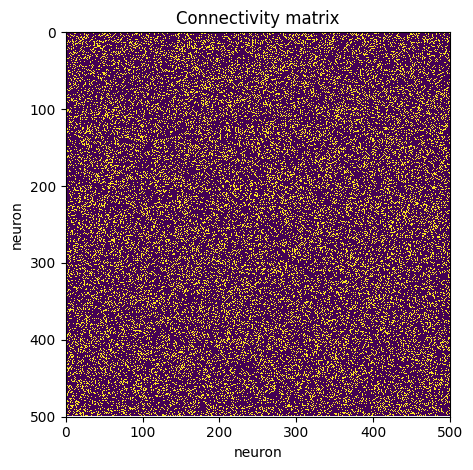

In [69]:
# 1) NETWORK SIZE
Ne = 400
Ni = 100
N = Ne + Ni
SIM_TIME = 3000

# 2) Izhikevich parameters (con variabilidad)
re = np.random.rand(Ne, 1)
ri = np.random.rand(Ni, 1)

a = np.vstack([0.02*np.ones((Ne,1)), 0.02 + 0.08*ri])
b = np.vstack([0.2*np.ones((Ne,1)),  0.25 - 0.05*ri])
c = np.vstack([-65 + 15*(re**2),     -65*np.ones((Ni,1))])
d = np.vstack([8 - 6*(re**2),         2*np.ones((Ni,1))])

# 3) Connectivity matrix A (Erdos-Renyi dirigido)
frac_delete = 0.8
A = np.random.rand(N, N)
A[A < frac_delete] = 0
A[A > 0] = 1
np.fill_diagonal(A, 0)

# Plot connectivity matrix (como tu script)
plt.figure()
plt.imshow(A, aspect='equal', interpolation='nearest')
plt.xlim(0, 500)
plt.ylim(500, 0)   # opcional: para que el 1 quede arriba; quita si no quieres
plt.xlabel('neuron')
plt.ylabel('neuron')
plt.title('Connectivity matrix')
plt.tight_layout()
plt.show()

# 4) Synaptic weights
MAX_EXC_WEIGTH = 4
MAX_INH_WEIGTH = 0.5

W = np.hstack([
    MAX_EXC_WEIGTH*np.random.rand(N, Ne),
    -MAX_INH_WEIGTH*np.random.rand(N, Ni)
])

# 5) Final weighted directed connectivity
S = A * W

# 6) Noise strength
NOISE_MAX = 3


(500, 500)
Percentage of connections: 0.544 %


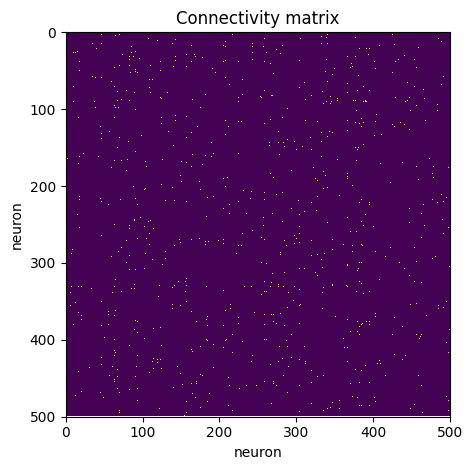

In [8]:
def load_A_for_alpha(alpha, folder="run0_txt"):
    fname = f"adjacency_test_a{alpha:0.3f}.txt"
    path = os.path.join(folder, fname)
    A = np.loadtxt(path, dtype=np.uint8)
    np.fill_diagonal(A, 0)
    return A

import os

# 1) NETWORK SIZE
Ne = 400
Ni = 100
N = Ne + Ni
SIM_TIME = 5000

# 2) Izhikevich parameters (con variabilidad)
re = np.random.rand(Ne, 1)
ri = np.random.rand(Ni, 1)

a = np.vstack([0.02*np.ones((Ne,1)), 0.02 + 0.08*ri])
b = np.vstack([0.2*np.ones((Ne,1)),  0.25 - 0.05*ri])
c = np.vstack([-65 + 15*(re**2),     -65*np.ones((Ni,1))])
d = np.vstack([8 - 6*(re**2),         2*np.ones((Ni,1))])

alpha = 0.002

A = load_A_for_alpha(alpha, folder="test_run000_txt")
print(A.shape)

# Percentage of connections
print("Percentage of connections:", A.sum() / (N*N) * 100, "%")
# 3) Asegura diagonal a 0 (por si acaso)
np.fill_diagonal(A, 0)

plt.figure()
plt.imshow(A, aspect='equal', interpolation='nearest')
plt.xlim(0, 500)
plt.ylim(500, 0)   # opcional: para que el 1 quede arriba; quita si no quieres
plt.xlabel('neuron')
plt.ylabel('neuron')
plt.title('Connectivity matrix')
plt.tight_layout()
plt.show()

# 5) Pesos y conectividad ponderada (igual que antes)
MAX_EXC_WEIGTH = 5.5
MAX_INH_WEIGTH = 0.5

W = np.hstack([
    MAX_EXC_WEIGTH*np.random.rand(N, Ne),
    -MAX_INH_WEIGTH*np.random.rand(N, Ni)
])

S = A * W

NOISE_MAX = 3

In [5]:
v = -65*np.ones((N, 1))
u = b * v

firings_t = []
firings_i = []

for t in range(1, SIM_TIME+1):
    I = np.vstack([NOISE_MAX*np.random.randn(Ne,1), 2*np.random.randn(Ni,1)])

    fired = np.where(v[:,0] >= 30)[0]  # índices (0..N-1)

    if fired.size > 0:
        firings_t.append(np.full(fired.shape, t, dtype=int))
        firings_i.append(fired.copy())

        v[fired] = c[fired]
        u[fired] = u[fired] + d[fired]

        # I = I + sum(S(:, fired), 2)
        # En numpy: sumamos columnas "fired" y nos queda vector Nx1
        I = I + np.sum(S[:, fired], axis=1, keepdims=True)

    # Integración (paso 0.5 ms x2)
    v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
    v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
    u = u + a*(b*v - u)

# Convertir lista de arrays a arrays planos
if len(firings_t) > 0:
    firings_t = np.concatenate(firings_t)
    firings_i = np.concatenate(firings_i) + 1  # +1 si quieres neuronas 1..N como en MATLAB
else:
    firings_t = np.array([], dtype=int)
    firings_i = np.array([], dtype=int)

print("Total spikes:", len(firings_t))


Total spikes: 1525


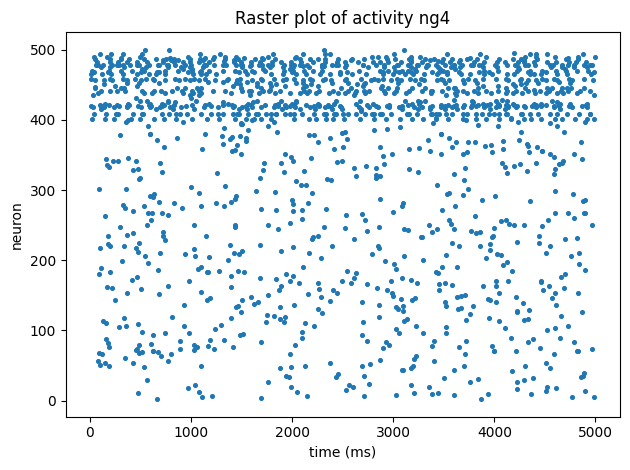

In [6]:
plt.figure()
plt.scatter(firings_t, firings_i, s=7)
plt.xlabel('time (ms)')
plt.ylabel('neuron')
plt.title('Raster plot of activity ng4')
plt.tight_layout()
plt.show()


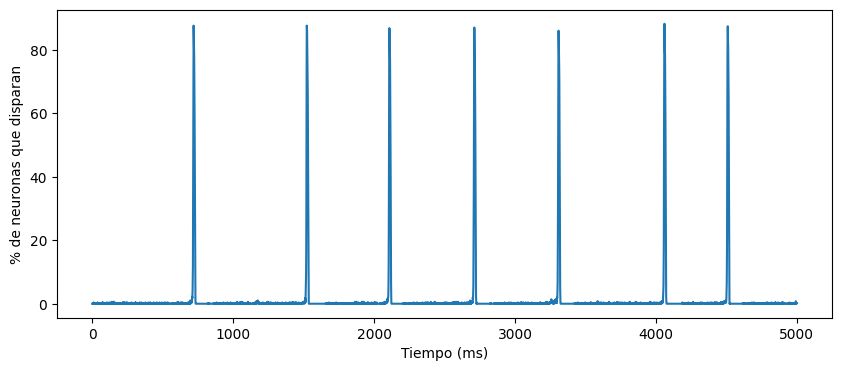

In [61]:
# spikes por timestep (vector de tamaño SIM_TIME+1)
spikes_per_t = np.bincount(firings_t, minlength=SIM_TIME+1)

# quitamos el índice 0 si tu simulación empieza en t=1
spikes_per_t = spikes_per_t[1:]

# porcentaje
percentage_firing = (spikes_per_t / N) * 100


import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(percentage_firing)
plt.xlabel("Tiempo (ms)")
plt.ylabel("% de neuronas que disparan")
plt.show()


In [60]:
SIM_TIME_SYNC = 1000
WINDOW = 100
num_active = np.zeros(10)

for j in range(1, 11):
    t0 = WINDOW*(j-1)
    t1 = WINDOW*j

    mask = (firings_t > t0) & (firings_t <= t1)
    neurons = firings_i[mask]
    if neurons.size == 0:
        num_active[j-1] = 0
    else:
        num_active[j-1] = len(np.unique(neurons)) / (Ne + Ni)

sync = np.max(num_active)
print("sync =", sync)
print("num_active per window =", num_active)


sync = 0.092
num_active per window = [0.05  0.052 0.092 0.08  0.072 0.066 0.06  0.066 0.078 0.082]
